In [1]:
from pathlib import Path
import sqlite3
import pandas as pd

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_PATH = PROJECT_ROOT / "database" / "customer_retention.db"

connection = sqlite3.connect(DATABASE_PATH)

query = """
SELECT
    c.customer_id,
    c.gender,
    c.age,
    c.married,
    c.number_of_dependents,
    c.number_of_referrals,
    c.tenure_months,
    c.churn,

    a.offer,
    a.contract,
    a.paperless_billing,
    a.payment_method,
    a.monthly_charge,
    a.total_charges,
    a.total_refunds,
    a.total_extra_data_charges,
    a.total_long_distance_charges,
    a.total_revenue,

    s.phone_service,
    s.avg_monthly_long_distance_charges,
    s.multiple_lines,
    s.internet_service,
    s.internet_type,
    s.avg_monthly_gb_download,
    s.online_security,
    s.online_backup,
    s.device_protection_plan,
    s.premium_tech_support,
    s.streaming_tv,
    s.streaming_movies,
    s.streaming_music,
    s.unlimited_data

FROM customers AS c

JOIN customer_accounts AS a
    ON c.customer_id = a.customer_id

JOIN customer_services AS s
    ON c.customer_id = s.customer_id

WHERE c.churn IS NOT NULL;
"""

df = pd.read_sql_query(query, connection)

connection.close()

df.shape

(6589, 32)

In [4]:
x = df.drop(columns = ["customer_id",
                       "churn"])
y = df["churn"].astype(int)

print(x.shape)
print(y.shape)

(6589, 30)
(6589,)


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

print("Training:", x_train.shape)
print("Testing:", x_test.shape)

print("\nTraining churn rate:")
print(y_train.mean())

print("\nTesting churn rate:")
print(y_test.mean())

Training: (5271, 30)
Testing: (1318, 30)

Training churn rate:
0.28362739518118

Testing churn rate:
0.283763277693475


In [8]:
numeric_features = x.select_dtypes(
    include = ["int64","float64"]).columns.tolist()

categorical_features = x.select_dtypes(
    include = ["object", "str"]).columns.tolist()

print("numeric features:", numeric_features)
print("\ncategorical features:", categorical_features)

numeric features: ['age', 'number_of_dependents', 'number_of_referrals', 'tenure_months', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'total_revenue', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download']

categorical features: ['gender', 'married', 'offer', 'contract', 'paperless_billing', 'payment_method', 'phone_service', 'multiple_lines', 'internet_service', 'internet_type', 'online_security', 'online_backup', 'device_protection_plan', 'premium_tech_support', 'streaming_tv', 'streaming_movies', 'streaming_music', 'unlimited_data']


In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    steps = [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [14]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, roc_auc_score

dummy_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]
)

dummy_model.fit(x_train, y_train)
dummy_predictions = dummy_model.predict(x_test)

print(classification_report(y_test, dummy_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.72      1.00      0.83       944
           1       0.00      0.00      0.00       374

    accuracy                           0.72      1318
   macro avg       0.36      0.50      0.42      1318
weighted avg       0.51      0.72      0.60      1318



In [15]:
from sklearn.linear_model import LinearRegression, LogisticRegression

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000,
                                          class_weight="balanced"))
    ]
)

logistic_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['gender','age','married',...,'streaming_movies','streaming_music', 'unlimited_data']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

In [17]:
logistic_predictions = logistic_model.predict(x_test)
logistic_probabilities = logistic_model.predict_proba(
    x_test
)[:, 1]

In [22]:
from sklearn.metrics import (
classification_report,
confusion_matrix,
roc_auc_score,
)

print(classification_report(y_test, logistic_predictions))
print("ROC-AUC:", roc_auc_score(y_test, logistic_probabilities))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, logistic_predictions))

              precision    recall  f1-score   support

           0       0.94      0.79      0.86       944
           1       0.63      0.87      0.73       374

    accuracy                           0.82      1318
   macro avg       0.78      0.83      0.79      1318
weighted avg       0.85      0.82      0.82      1318

ROC-AUC: 0.9139513278346778

Confusion Matrix:
[[750 194]
 [ 49 325]]


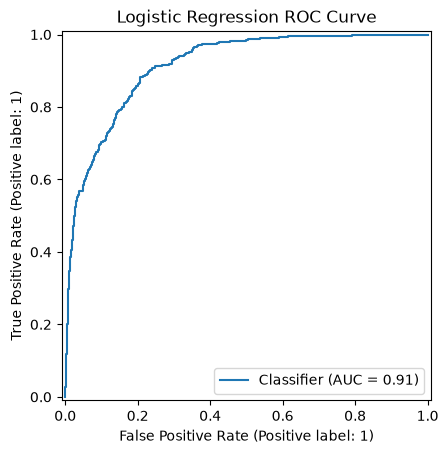

In [23]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_test, logistic_probabilities)
plt.title("Logistic Regression ROC Curve")
plt.show()